# EDA (Exploratory Data Analysis) for Final Merged dataset

In [1]:
#Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import numpy as np
from pathlib import Path

# Set display and style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

In [2]:
#Loading Merged Final Dataset

dfmerged_path = Path('/Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject/data/processed/merged_factcheck_dataset.csv')

df_merged = pd.read_csv(dfmerged_path)

### Basic Overview of Merged Dataset

In [5]:
print("Dataset Overview")
print(f"Shape: {df_merged.shape}")
print("\nColumns:", list(df_merged.columns))
print("\nSample Rows:")
display(df_merged.sample(25, random_state=42))

print("\n Missing Values Summary")
print(df_merged.isnull().sum())

print("\n Verdict Distribution")
print(df_merged['verdict_mapped'].value_counts(normalize=True) * 100)

Dataset Overview
Shape: (25540, 8)

Columns: ['claim_id', 'claim_text', 'verdict_original', 'verdict_mapped', 'summary', 'originator', 'url', 'dataset_source']

Sample Rows:


,claim_id,claim_text,verdict_original,verdict_mapped,summary,originator,url,dataset_source
2166,P02167,Speedway is offering $500 fuel cards for $1.95...,pants-fire,Likely False,NaN,Facebook posts,https://www.politifact.com/factchecks/2022/jun...,PolitiFact
16560,P16561,"""The federal government borrows $4 billion eve...",mostly-true,Likely True,NaN,National Republican Congressional Committee,https://www.politifact.com/factchecks/2011/may...,PolitiFact
5570,P05571,"""Yale study: Vaccinated people more likely to ...",false,Likely False,NaN,Instagram posts,https://www.politifact.com/factchecks/2022/jan...,PolitiFact
4219,P04220,"""The people that went to school with (Barack O...",pants-fire,Likely False,NaN,Donald Trump,https://www.politifact.com/factchecks/2011/feb...,PolitiFact
11286,P11287,Said former U.S. Ambassador to Kenya Scott Gra...,mostly-false,Likely False,NaN,David Shuster,https://www.politifact.com/factchecks/2015/mar...,PolitiFact
341,P00342,"""The Canadian government threatens to fire any...",pants-fire,Likely False,NaN,Facebook posts,https://www.politifact.com/factchecks/2021/oct...,PolitiFact
20565,P20566,"Says after the shooting in El Paso, ""on Sunday...",false,Likely False,NaN,Dan Patrick,https://www.politifact.com/factchecks/2019/aug...,PolitiFact
10465,P10466,Oregon’s budget has grown by 49 percent in jus...,mostly-true,Likely True,NaN,Allen Alley,https://www.politifact.com/factchecks/2010/nov...,PolitiFact
14826,P14827,"""In 2012, 123 African-Americans were shot dead...",mostly-false,Likely False,NaN,Bill O'Reilly,https://www.politifact.com/factchecks/2014/dec...,PolitiFact
14411,P14412,Treasury Department's inspector general found ...,half-true,Uncertain,NaN,Jeff Sessions,https://www.politifact.com/factchecks/2017/apr...,PolitiFact



 Missing Values Summary
claim_id                0
claim_text              0
verdict_original        0
verdict_mapped          0
summary             21152
originator           4388
url                  4388
dataset_source          0
dtype: int64

 Verdict Distribution
verdict_mapped
Likely False    56.342991
Likely True     25.552075
Uncertain       18.104933
Name: proportion, dtype: float64


In [12]:
#Saving Cleaned Dataset
output_path = Path('/Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject/data/processed/merged_factcheck_datasetcleaned.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_merged.to_csv(output_path, index=False)
print(f"\n Cleaned Final dataset saved to:\n{output_path}")


 Cleaned Final dataset saved to:
/Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject/data/processed/merged_factcheck_datasetcleaned.csv


a. Dataset Shape and Columns

- The dataset has 25,540 rows and 8 columns. The schema is consistent and clean, with no redundant fields. The columns provide a balanced structure for both retrieval (claim_text, url, summary) and supervised training (verdict_mapped).

b. Missing Values

- `summary`: Missing for 21,152 rows (PolitiFact entries).
- `originator` and `url`: Missing for about 4,388 rows (Snopes entries).
  
These missing values are expected since Snopes and PolitiFact have different metadata availability. They are not harmful for model training because our core features (claim_text, verdict_mapped) are complete. These columns will primarily be useful for retrieval UI display, not learning.

c. Verdict Distribution

Likely False: 56.34%

Likely True: 25.55%

Uncertain: 18.10%

The dataset is moderately imbalanced, skewed toward "Likely False". This means the classifier may overpredict “False” if trained without countermeasures. The imbalance is not extreme but significant enough to require techniques like Applying class weighting during model training, or Using oversampling or undersampling for balance checks.


- Overall, the dataset is clean, well-structured, and ready for analysis.

### Text Length Analysis


 Claim Text Length Statistics
count    25540.000000
mean        17.779561
std          7.684988
min          1.000000
25%         12.000000
50%         16.000000
75%         22.000000
max         79.000000
Name: claim_length, dtype: float64


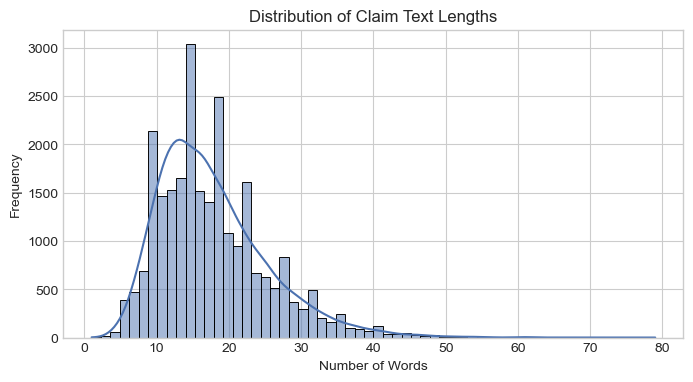

In [6]:
df_merged['claim_length'] = df_merged['claim_text'].apply(lambda x: len(x.split()))
print("\n Claim Text Length Statistics")
print(df_merged['claim_length'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df_merged['claim_length'], bins=60, kde=True)
plt.title("Distribution of Claim Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

- From the above plot we can see these key statistics :
  - Mean claim length: ~17.8 words
  - Median claim length: 16 words
  - 75% of claims are under 22 words
  - Maximum observed: 79 words
  - Minimum: 1 word

This indicates that most claims are short, concise statements typical of fact-checking datasets, where claims are often quoted sentences or brief assertions. The average range (12–22 words) is manageable for transformer-based models like DistilBERT without causing sequence truncation issues.

- The histogram is right-skewed, meaning there are many short claims (5–25 words) and relatively few long ones.

- The dataset’s text length is well-suited for sentence-level embeddings (e.g., Sentence-BERT, MiniLM) and there are No outliers that require removal even the longest 79-word claims are well below 512-token transformer limits.

### Source vs Verdict Distribution

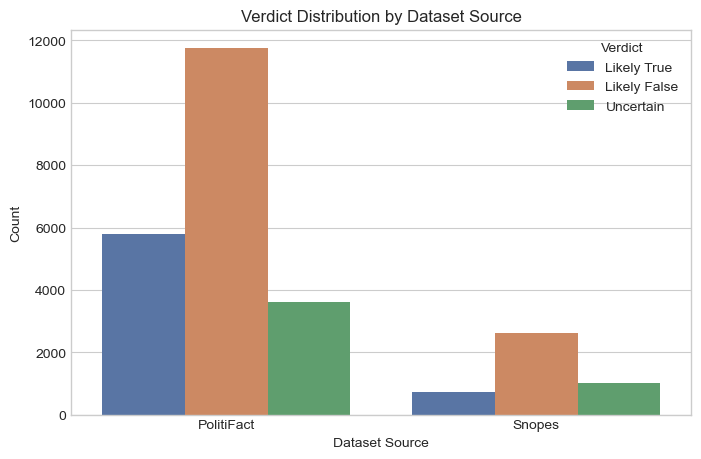

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_merged, x='dataset_source', hue='verdict_mapped')
plt.title("Verdict Distribution by Dataset Source")
plt.xlabel("Dataset Source")
plt.ylabel("Count")
plt.legend(title="Verdict", loc='upper right')
plt.show()

- This chart clearly shows that PolitiFact dominates the merged dataset both in size and verdict diversity, while Snopes contributes fewer samples.

- PolitiFact Dataset:
   - Largest contributor (~80% of total).
   - Heavily weighted toward “Likely False” (~12K) and “Likely True” (~6K).
   - Moderate presence of “Uncertain” (~4K).

Overall this shows decently balanced distribution across all three labels.

- Snopes Dataset is Much smaller (~1/4th size of PolitiFact).

It Still shows a similar but milder skew toward “Likely False.”


- The class imbalance originates mainly from PolitiFact it has many more “False” claims. There’s no major domain conflict: both datasets share similar verdict distributions, which means merging them is semantically consistent.The merged dataset remains imbalanced, but consistent across sources, so the model won’t be biased toward one data origin.

- For Mitigating this during Model training, Apply class weighting to balance “Likely True” and “Uncertain” against “Likely False' and Ensure stratified sampling for validation/testing splits so that both sources and verdicts are proportionally represented.

### Overall Verdict Distribution

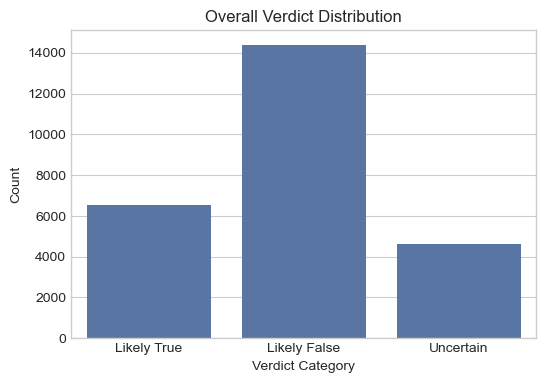

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='verdict_mapped', data=df_merged, order=['Likely True', 'Likely False', 'Uncertain'])
plt.title("Overall Verdict Distribution")
plt.xlabel("Verdict Category")
plt.ylabel("Count")
plt.show()

- The bar chart clearly shows that “Likely False” is the dominant label, followed by “Likely True” and then “Uncertain" with approximate proportions: Likely False: ~56%, Likely True: ~26% and Uncertain: ~18%.

- This confirms a moderate class imbalance, with the “Likely False” category more than doubling the “Uncertain” class. This skew is typical in real-world fact-checking data, where false or misleading claims are more frequently fact-checked than true ones.

- In the context of Model Training Without adjustment, the classifier will tend to overpredict “Likely False” because of the data distribution. Validation metrics like accuracy would be misleading and we need to use F1-score or macro-averaged precision/recall to fairly evaluate performance.

- The dataset has realistic but learnable imbalance. It doesn’t need synthetic augmentation yet weighting or stratified batching will suffice. This confirms the merged dataset’s integrity and makes it suitable for training a robust classifier.

### Average Claim Length per Verdict

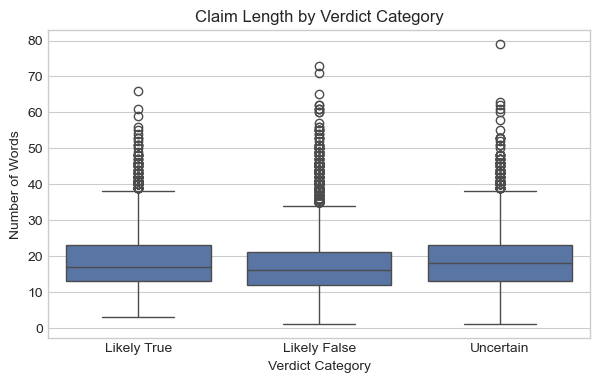

In [9]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_merged, x='verdict_mapped', y='claim_length', order=['Likely True', 'Likely False', 'Uncertain'])
plt.title("Claim Length by Verdict Category")
plt.xlabel("Verdict Category")
plt.ylabel("Number of Words")
plt.show()

- This boxplot compares claim lengths across verdict categories (“Likely True,” “Likely False,” and “Uncertain”) and we can see that All three categories show Similar median lengths around **16–18 words**, with a few long outliers (50–80 words).

- Claim length does not influence or predict verdicts and fact-checkers label short and long claims similarly.

- In the context of Model Design we can safely ignore `claim_length` as an explicit feature and it won’t add predictive power.

### WordClouds by Verdict

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


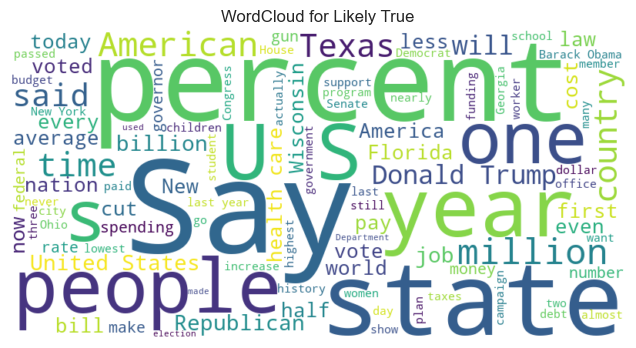

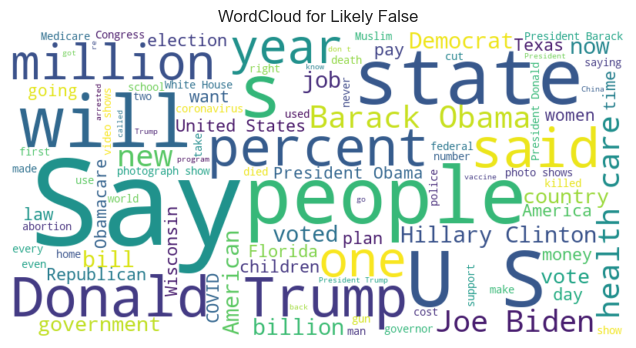

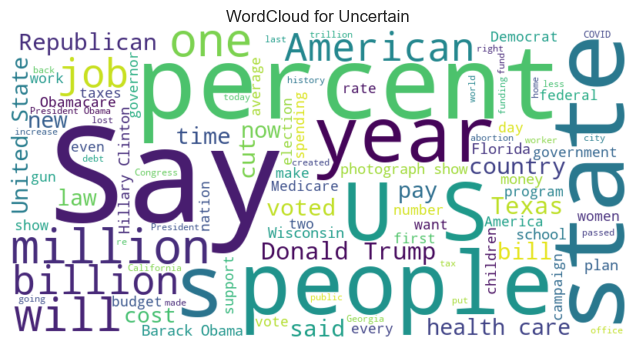

In [10]:
for label in ['Likely True', 'Likely False', 'Uncertain']:
    text = " ".join(df_merged[df_merged['verdict_mapped'] == label]['claim_text'].astype(str))
    plt.figure(figsize=(8, 4))
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {label}")
    plt.show()

- These three word clouds visualize the most common tokens used in claim texts for each verdict category (“Likely True,” “Likely False,” “Uncertain”). The visualization highlights lexical patterns and frequently referenced topics.

- Observations by Category:

* **Likely True:**
  Frequent terms: *percent, year, people, state, say, American, Texas, Trump, Florida, billion, country.*

  
These claims are often Data-driven (percentages, years, numbers) and contextually grounded (geographical or economic references). It suggests “Likely True” claims tend to involve measurable statistics or official data.

* **Likely False:**
  Frequent terms: *say, people, will, state, Trump, Obama, Biden, health care, bill, million, COVID.*

These claims include Names of political figures and policy-related terms. Indicates “Likely False” statements often come from Political discourse or misinformation tied to trending topics.

* **Uncertain:**
  Frequent terms: *say, percent, people, year, state, job, American, Trump, Biden, Republican, health care.*

These claims blend factual and speculative elements and has strong overlap with “True” and “False” but with softer linguistic cues. “Uncertain” claims often use Neutral or incomplete phrasing, lacking clear verifiability.


- In the context of Model Training Models must be Context-sensitive which implies transformers or sentence encoders are ideal.

### Dataset Source Proportion

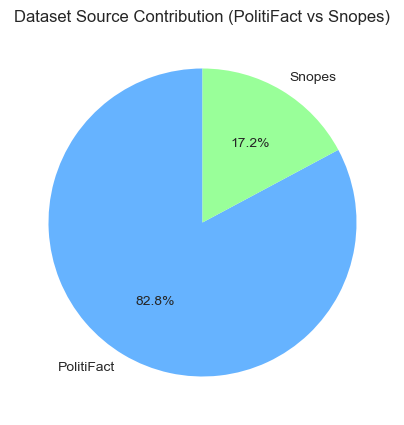

In [11]:
plt.figure(figsize=(5, 5))
df_merged['dataset_source'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title("Dataset Source Contribution (PolitiFact vs Snopes)")
plt.ylabel("")
plt.show()

- The dataset is heavily dominated by PolitiFact, contributing more than four-fifths of all claims. Snopes plays a supporting role, but it does add diversity especially since it contains claim summaries and a few unique labeling conventions (“Mixture,” “Miscaptioned,” etc.) that were mapped into your unified scheme.
- In the context of Model Training & Retrieval, When splitting data into training and testing sets, applying stratification by both verdict and dataset_source to avoid leakage where we don’t want the model to overfit to PolitiFact’s phrasing patterns.